# Dataset overview

## Library import and settings

In [2]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format)


## Download the Dataset

In [3]:
listings = pd.read_csv("../data/raw/listings.csv")


## Basic Characteristic of the Dataset

### Shape

In [4]:
listings.shape


(2852, 18)

### Schema

In [5]:
listings.info()


<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2852 non-null   int64  
 1   name                            2852 non-null   str    
 2   host_id                         2852 non-null   int64  
 3   host_name                       2849 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   2852 non-null   int64  
 6   latitude                        2852 non-null   float64
 7   longitude                       2852 non-null   float64
 8   room_type                       2852 non-null   str    
 9   price                           2537 non-null   float64
 10  minimum_nights                  2852 non-null   int64  
 11  number_of_reviews               2852 non-null   int64  
 12  last_review                     2609 non-null

**id** — unique listing identifier  
**name** — listing title    
**host_id** — unique host/landlord identifier   
**host_name** — host/landlord name      
**neighbourhood_group** — larger administrative area grouping of the neighbourhood     
**neighbourhood** — neighborhood where the property is located  
**latitude** — property latitude    
**longitude** — property longitude  
**room_type** — type of accommodation offered: `Entire home/apt`, `Private room`, `Shared room`, `Hotel room`   
**price** — price per night     
**minimum_nights** — minimum number of nights required for booking  
**number_of_reviews** — total number of reviews     
**last_review** — date of the most recent review    
**reviews_per_month** — average number of reviews per month     
**calculated_host_listings_count** — number of active listings for this host    
**availability_365** — number of days per year the property is available for booking    
**number_of_reviews_ltm** — number of reviews in the last 12 months (`ltm` = `last twelve months`)  
**license** — license/permit number for short-term rental   


In [6]:
listings.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.5786,-82.5958,Entire home/apt,96.0000,1,463,2025-09-01,2.6900,8,70,23,NaN
1,197263,Tranquil Room & Private Bath,961396,Timothy,NaN,28806,35.5774,-82.6380,Private room,44.0000,2,90,2025-09-01,0.5600,2,88,3,NaN
2,209068,Terrace Cottage,1029919,Kevin,NaN,28804,35.6176,-82.5518,Entire home/apt,90.0000,30,67,2025-05-03,0.3900,1,268,2,NaN
3,246315,Asheville Dreamer's Cabin,1292070,Annie,NaN,28805,35.5962,-82.5063,Private room,62.0000,7,53,2019-10-30,0.3100,3,70,0,NaN
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,NaN,28806,35.5856,-82.6273,Entire home/apt,221.0000,1,36,2025-06-23,0.2200,1,180,7,NaN


## Duplicated Values

In [7]:
listings.duplicated().sum().item()


0

In [8]:
listings["id"].nunique() / listings["id"].shape[0]


1.0

In [9]:
listings["host_id"].nunique() / listings.shape[0]


0.6160589060308556

In [10]:
listings.duplicated(subset=["latitude", "longitude"]).sum().item() / listings.shape[0]


0.04102384291725105

## Missing and Null Values 

<Axes: >

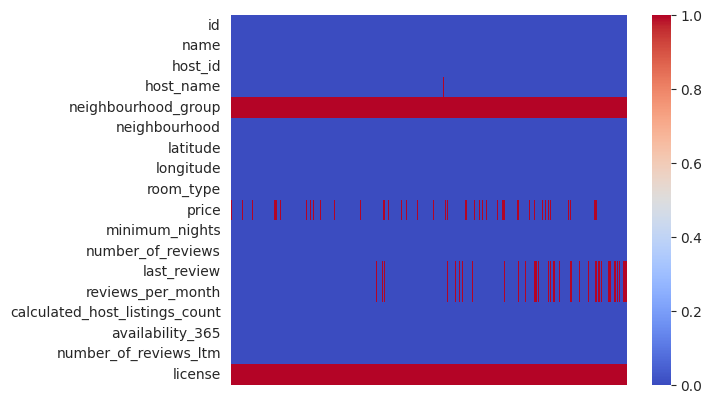

In [11]:
sns.heatmap(listings.isnull().T, xticklabels=False, cmap="coolwarm")



In [12]:
listings.isna().mean()[listings.isna().mean() != 0]


host_name             0.0011
neighbourhood_group   1.0000
price                 0.1104
last_review           0.0852
reviews_per_month     0.0852
license               1.0000
dtype: float64

### Check last_review and reviews_per_month are Null at the same time

In [13]:
print((listings["last_review"].isna() == listings["reviews_per_month"].isna()).mean())


1.0


### Check neighbourhood_group and licence are empty

In [14]:
print(listings["neighbourhood_group"].isna().mean())
print(listings["license"].isna().mean())


1.0
1.0


## Values Uniqueness 

In [15]:
listings.nunique()


id                                2852
name                              2842
host_id                           1757
host_name                          987
neighbourhood_group                  0
neighbourhood                        8
latitude                          2571
longitude                         2579
room_type                            4
price                              470
minimum_nights                      27
number_of_reviews                  510
last_review                        490
reviews_per_month                  645
calculated_host_listings_count      23
availability_365                   360
number_of_reviews_ltm               99
license                              0
dtype: int64

In [16]:
listings["neighbourhood"].unique()


array([28806, 28804, 28805, 28803, 28801, 28704, 28732, 28715])

In [17]:
listings["room_type"].unique()


<StringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: str

## Univariate Analysis

In [18]:
listings.describe()


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,2852.0000,2852.0000,0.0000,2852.0000,2852.0000,2852.0000,2537.0000,2852.0000,2852.0000,2609.0000,2852.0000,2852.0000,2852.0000,0.0000
mean,496846489244253760.0000,171554630.2083,NaN,28791.9947,35.5749,-82.5575,196.3839,6.2013,113.7156,2.1780,9.6466,223.5550,12.9632,NaN
std,546376155207300672.0000,177553153.8102,NaN,31.0008,0.0496,0.0484,405.6750,20.5200,157.7760,1.9916,23.3005,122.2471,18.2980,NaN
min,155305.0000,4134.0000,NaN,28704.0000,35.4271,-82.6699,18.0000,1.0000,0.0000,0.0200,1.0000,0.0000,0.0000,NaN
25%,33522362.5000,29236831.5000,NaN,28801.0000,35.5548,-82.5918,95.0000,1.0000,11.0000,0.6900,1.0000,116.0000,1.0000,NaN
50%,53565572.0000,112295380.0000,NaN,28803.0000,35.5868,-82.5559,133.0000,2.0000,57.0000,1.6400,2.0000,263.0000,5.0000,NaN
75%,1000807194381625088.0000,247281413.7500,NaN,28806.0000,35.6058,-82.5190,211.0000,2.0000,147.0000,3.0900,4.0000,332.0000,19.0000,NaN
max,1513869641491207424.0000,712503741.0000,NaN,28806.0000,35.6581,-82.4602,9999.0000,730.0000,1473.0000,20.2900,113.0000,365.0000,255.0000,NaN


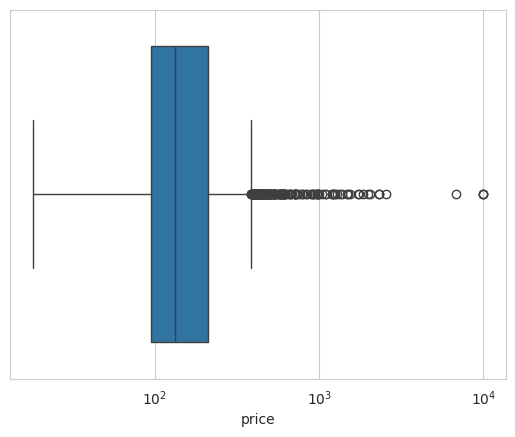

In [19]:
sns.boxplot(x=listings['price'])
plt.xscale('log')


<Axes: xlabel='neighbourhood', ylabel='count'>

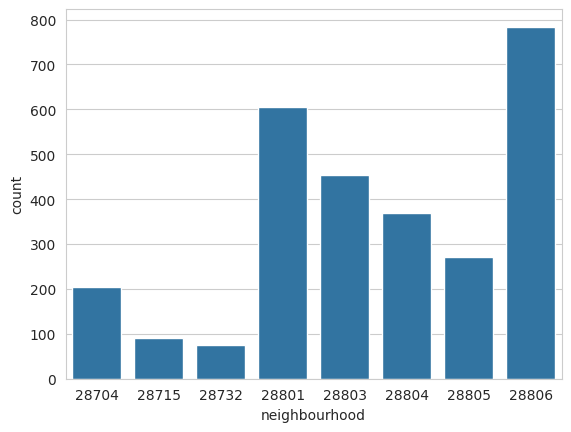

In [20]:
sns.countplot(data=listings, x="neighbourhood")


## Bivariate Analysis

## Multivariate Analysis

## Quality check

In [29]:
print(((listings["number_of_reviews"] == 0) == (listings["last_review"].isna() & listings["reviews_per_month"].isna())).mean())


1.0


In [33]:
listings[listings["price"] <= 0]


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
